# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rickyjackson/quebec-housing-sales-price/quebec_housing_sales_v2.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/rickyjackson/quebec-housing-sales-price/quebec_housing_sales_v2.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,property_id,city,neighborhood,property_type,bedrooms,bathrooms,living_area_sqft,lot_size_sqft,year_built,renovation_year,garage,basement,sale_year,sale_price
0,1,Châteauguay,Centre-Ville,Townhouse,3,2,1160,2304.0,2022,NaN,Yes,No,2024,326000
1,2,Trois-Rivières,Cap-de-la-Madeleine,Duplex,4,4,1807,5869.0,2006,2024.0,No,Yes,2025,444000
2,3,Lévis,Charny,Townhouse,3,1,803,3387.0,1989,NaN,Yes,Yes,2025,273000
3,4,Laval,Fabreville,Single Family,3,3,1083,11417.0,1972,2016.0,Yes,Yes,2023,465000
4,5,Longueuil,Greenfield Park,Condo,2,2,714,NaN,1997,2010.0,Yes,No,2022,371000


## last Five row

In [4]:
df.tail()

,property_id,city,neighborhood,property_type,bedrooms,bathrooms,living_area_sqft,lot_size_sqft,year_built,renovation_year,garage,basement,sale_year,sale_price
4995,4996,Sherbrooke,Lennoxville,Single Family,4,4,1411,9036.0,1985,NaN,Yes,No,2023,406000
4996,4997,Rimouski,Rimouski Centre,Single Family,5,2,1432,6474.0,2010,NaN,Yes,No,2022,198000
4997,4998,Montréal,Villeray,Duplex,4,2,1692,6070.0,1953,NaN,Yes,No,2024,680000
4998,4999,Brossard,Secteur B,Bungalow,2,1,954,4686.0,1994,2013.0,Yes,Yes,2024,431000
4999,5000,Terrebonne,Lachenaie,Condo,1,1,861,NaN,1969,2010.0,Yes,No,2021,472000


## Shape of our dataset

In [5]:
df.shape

(5000, 14)

## List out all columns

In [6]:
df.columns

Index(['property_id', 'city', 'neighborhood', 'property_type', 'bedrooms',
       'bathrooms', 'living_area_sqft', 'lot_size_sqft', 'year_built',
       'renovation_year', 'garage', 'basement', 'sale_year', 'sale_price'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

property_id           int64
city                 object
neighborhood         object
property_type        object
bedrooms              int64
bathrooms             int64
living_area_sqft      int64
lot_size_sqft       float64
year_built            int64
renovation_year     float64
garage               object
basement             object
sale_year             int64
sale_price            int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       5000 non-null   int64  
 1   city              5000 non-null   object 
 2   neighborhood      5000 non-null   object 
 3   property_type     5000 non-null   object 
 4   bedrooms          5000 non-null   int64  
 5   bathrooms         5000 non-null   int64  
 6   living_area_sqft  5000 non-null   int64  
 7   lot_size_sqft     3789 non-null   float64
 8   year_built        5000 non-null   int64  
 9   renovation_year   1592 non-null   float64
 10  garage            5000 non-null   object 
 11  basement          5000 non-null   object 
 12  sale_year         5000 non-null   int64  
 13  sale_price        5000 non-null   int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 547.0+ KB


## Check Null Value

In [9]:
df.isnull().sum()

property_id            0
city                   0
neighborhood           0
property_type          0
bedrooms               0
bathrooms              0
living_area_sqft       0
lot_size_sqft       1211
year_built             0
renovation_year     3408
garage                 0
basement               0
sale_year              0
sale_price             0
dtype: int64

## Drop Null Values

In [10]:
df.drop(columns=['lot_size_sqft', 'renovation_year'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,property_id,bedrooms,bathrooms,living_area_sqft,year_built,sale_year,sale_price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,2500.500000,3.488200,2.325800,1313.693800,1983.074000,2023.411600,4.802140e+05
std,1443.520003,1.357435,0.968009,472.106052,26.483028,1.332119,1.771254e+05
min,1.000000,1.000000,1.000000,469.000000,1900.000000,2021.000000,1.140000e+05
25%,1250.750000,2.000000,2.000000,915.000000,1966.000000,2022.000000,3.527500e+05
50%,2500.500000,3.000000,2.000000,1273.000000,1985.000000,2024.000000,4.530000e+05
75%,3750.250000,4.000000,3.000000,1650.000000,2004.000000,2025.000000,5.840000e+05
max,5000.000000,8.000000,6.000000,2967.000000,2023.000000,2025.000000,1.425000e+06


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

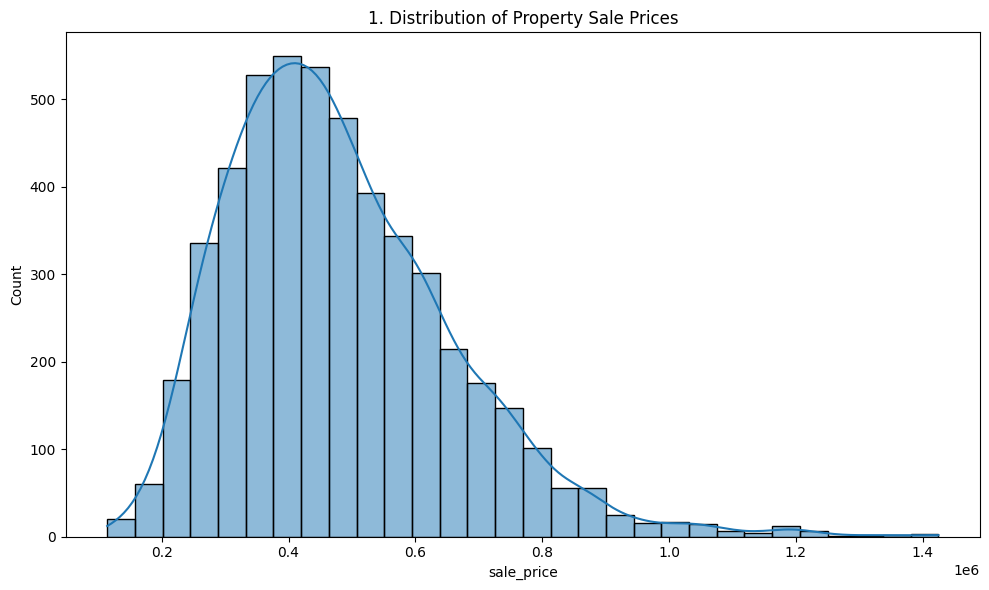

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['sale_price'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Property Sale Prices')
show_fig()
plot_no += 1

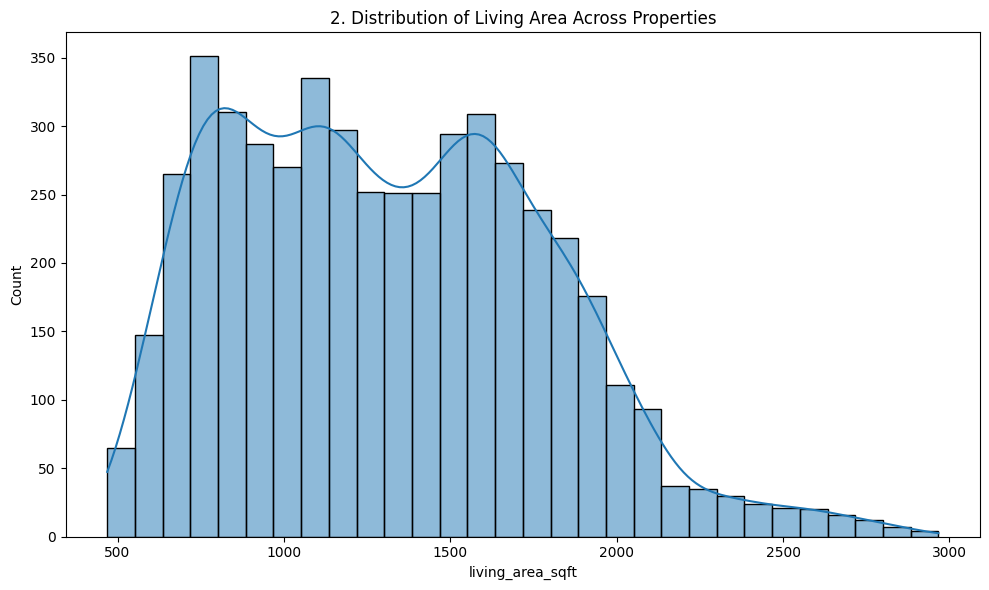

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['living_area_sqft'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Living Area Across Properties')
show_fig()
plot_no += 1

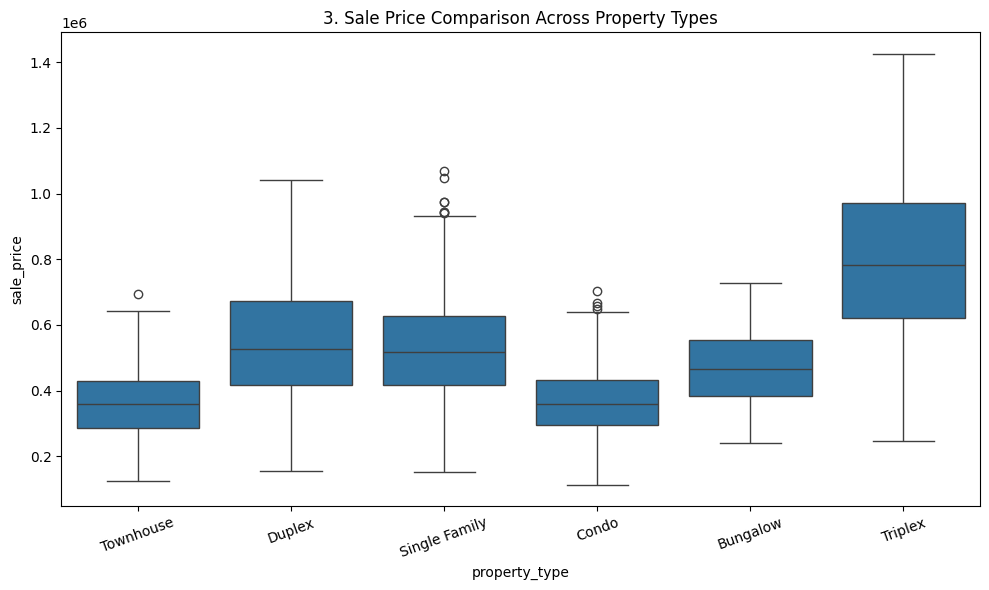

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='property_type', y='sale_price', data=df)
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Sale Price Comparison Across Property Types')
show_fig()
plot_no += 1

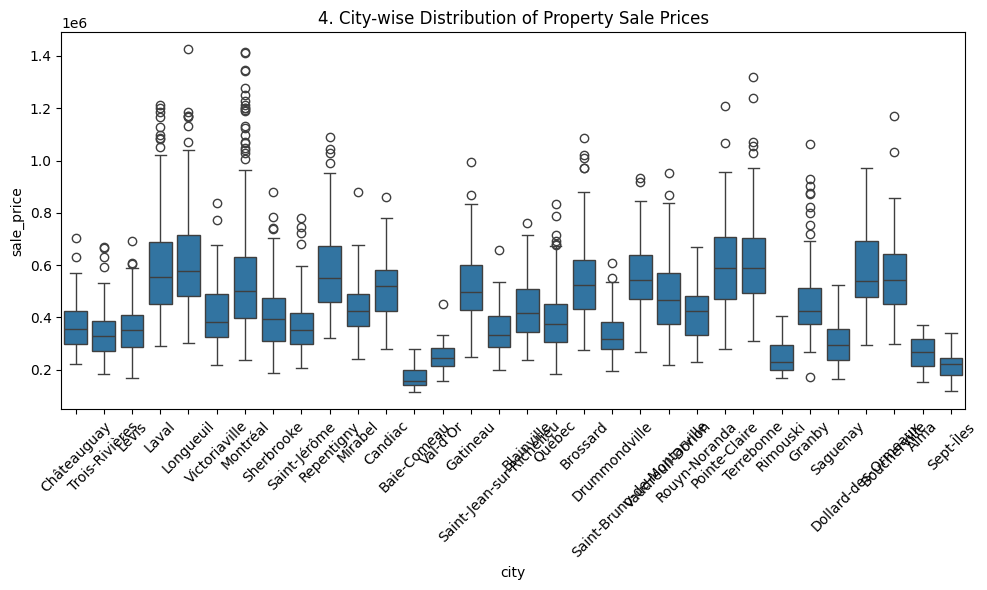

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='city', y='sale_price', data=df)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. City-wise Distribution of Property Sale Prices')
show_fig()
plot_no += 1

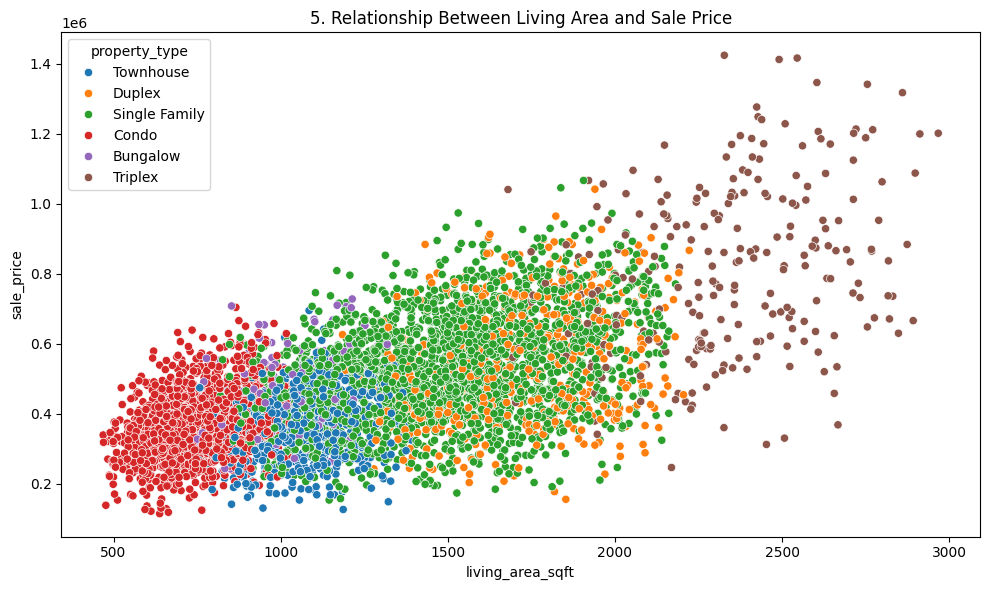

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='living_area_sqft', y='sale_price', hue='property_type', data=df)
plt.title(f'{plot_no}. Relationship Between Living Area and Sale Price')
show_fig()
plot_no += 1

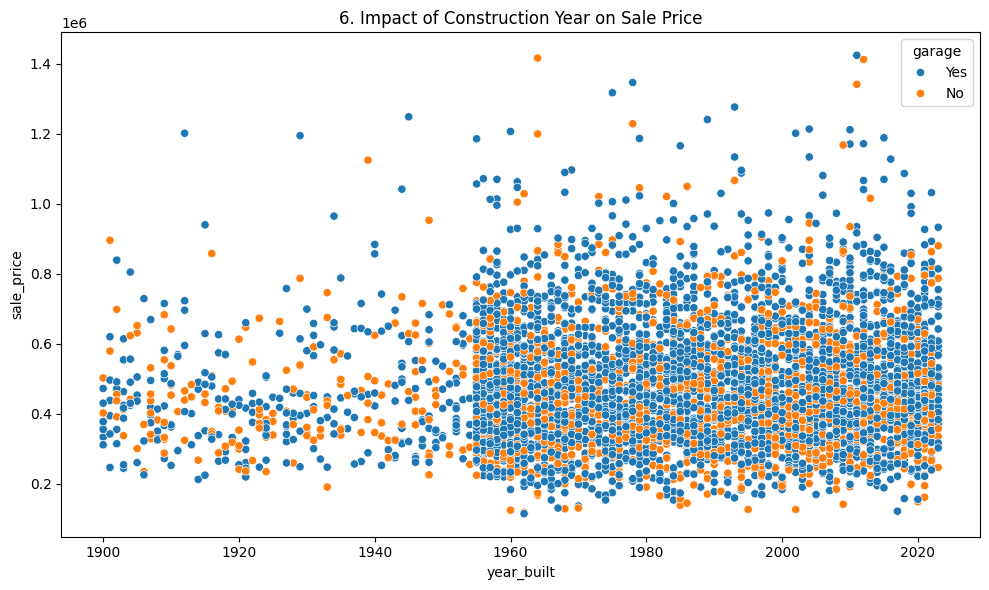

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='year_built', y='sale_price', hue='garage', data=df)
plt.title(f'{plot_no}. Impact of Construction Year on Sale Price')
show_fig()
plot_no += 1

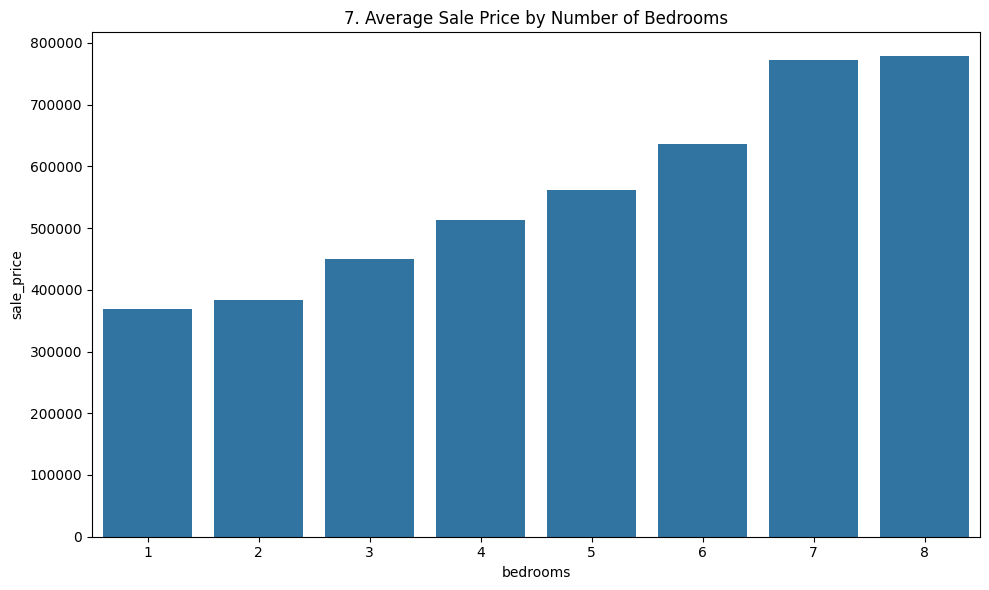

In [20]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='bedrooms', y='sale_price', data=df, estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Sale Price by Number of Bedrooms')
show_fig()
plot_no += 1

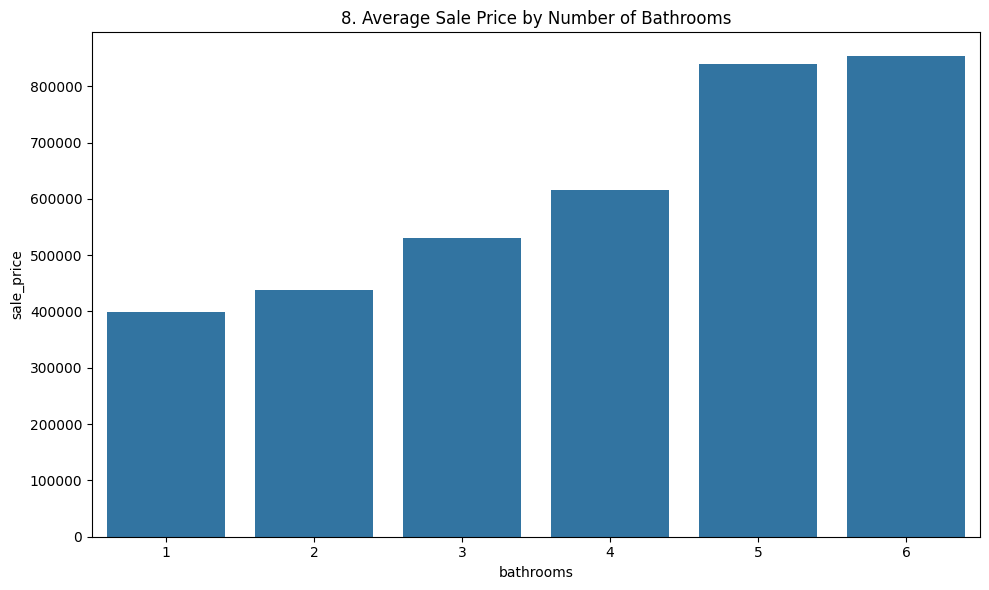

In [21]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='bathrooms', y='sale_price', data=df, estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Sale Price by Number of Bathrooms')
show_fig()
plot_no += 1

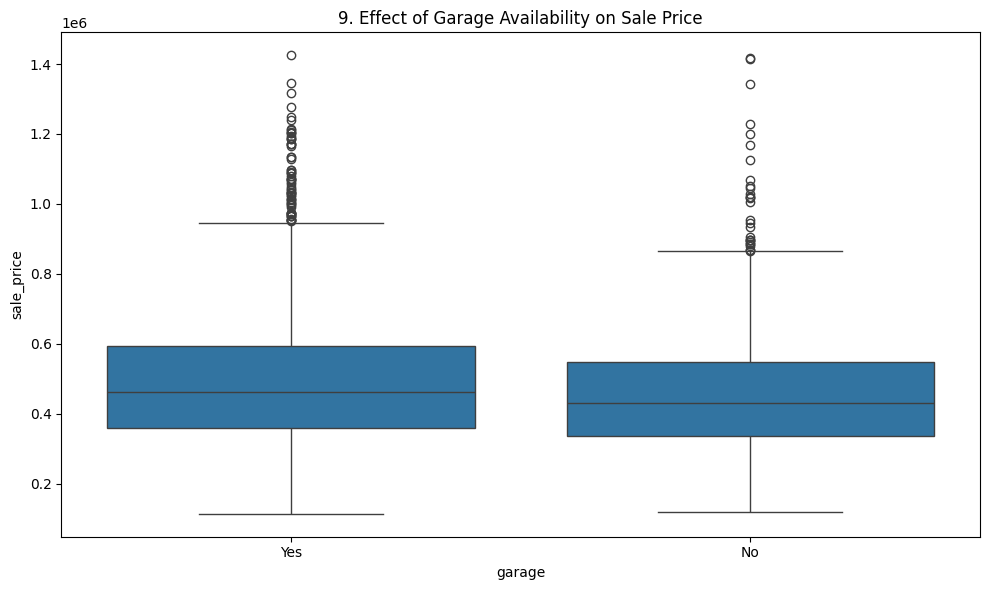

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='garage', y='sale_price', data=df)
plt.title(f'{plot_no}. Effect of Garage Availability on Sale Price')
show_fig()
plot_no += 1

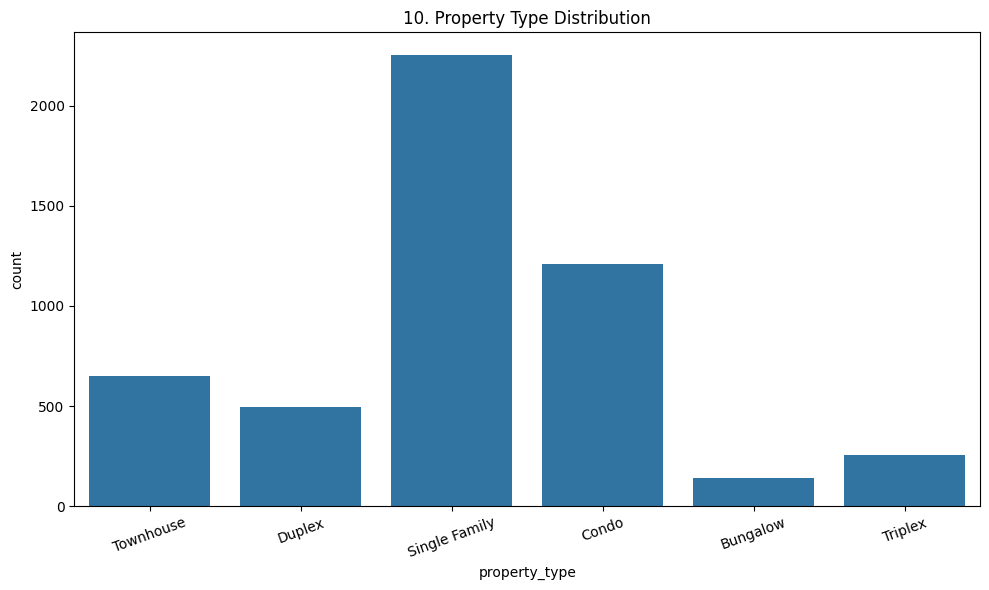

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='property_type', data=df)
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Property Type Distribution')
show_fig()
plot_no += 1

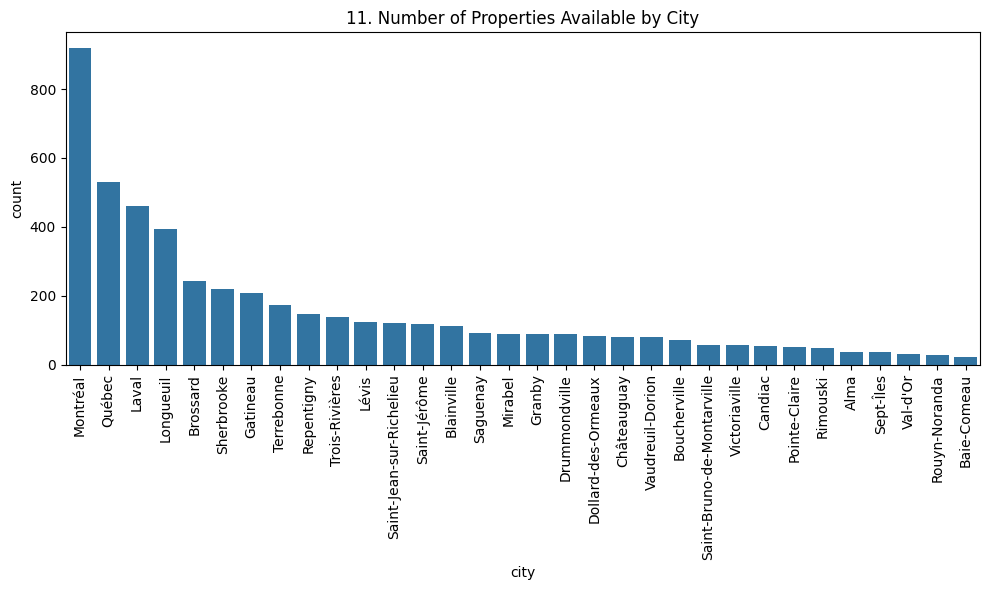

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='city', data=df, order=df['city'].value_counts().index)
plt.xticks(rotation=90)
plt.title(f'{plot_no}. Number of Properties Available by City')
show_fig()
plot_no += 1

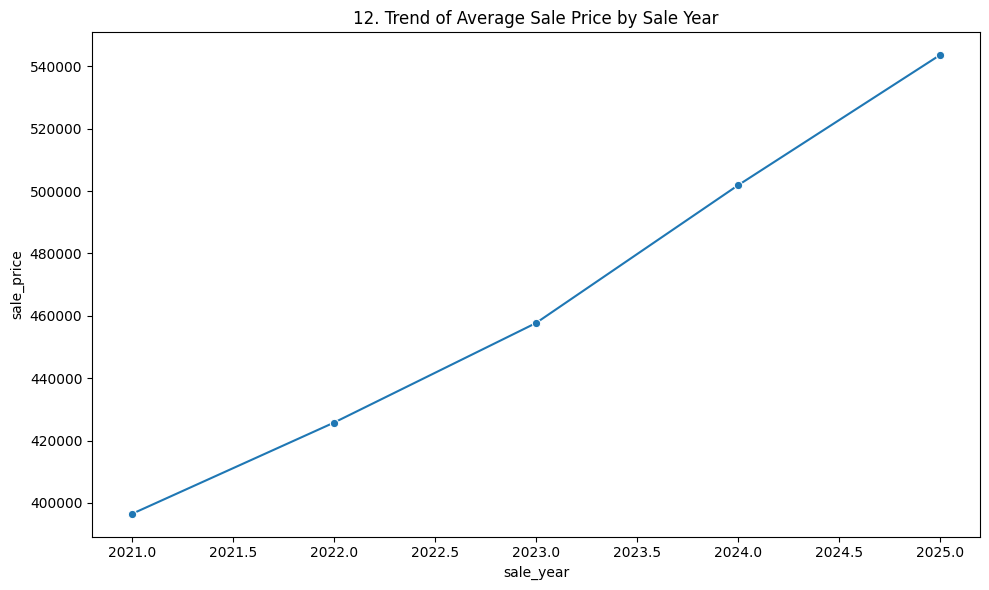

In [25]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x='sale_year', y='sale_price', data=df, estimator='mean', errorbar=None, marker='o')
plt.title(f'{plot_no}. Trend of Average Sale Price by Sale Year')
show_fig()
plot_no += 1

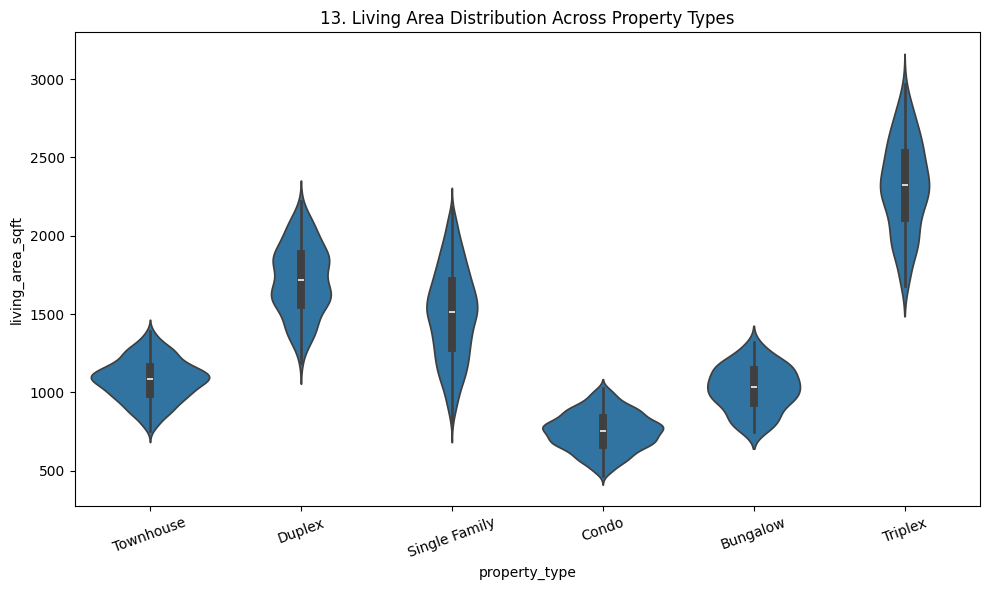

In [26]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='property_type', y='living_area_sqft', data=df)
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Living Area Distribution Across Property Types')
show_fig()
plot_no += 1

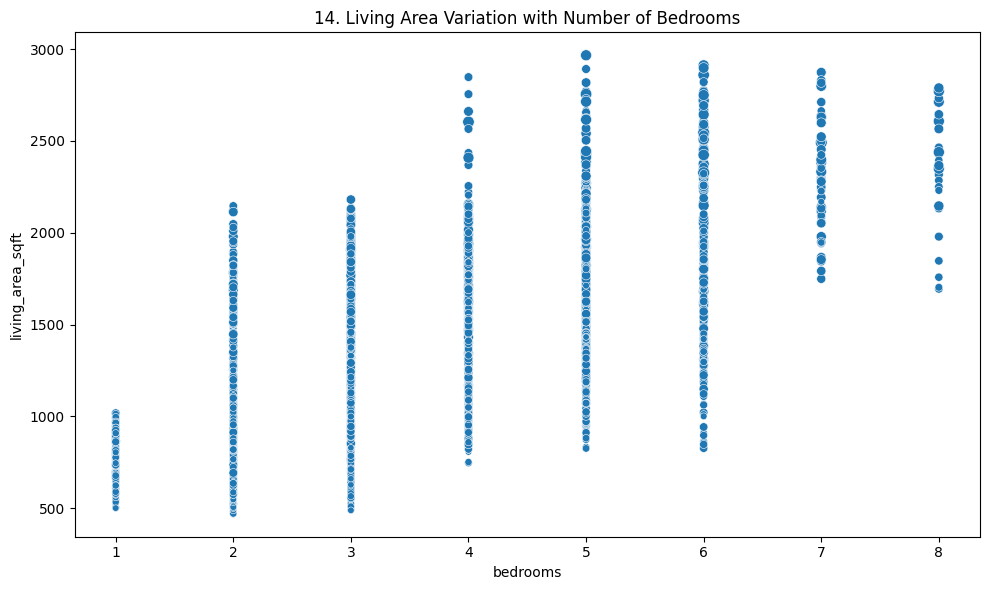

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='bedrooms', y='living_area_sqft', size='sale_price', data=df, legend=False)
plt.title(f'{plot_no}. Living Area Variation with Number of Bedrooms')
show_fig()
plot_no += 1

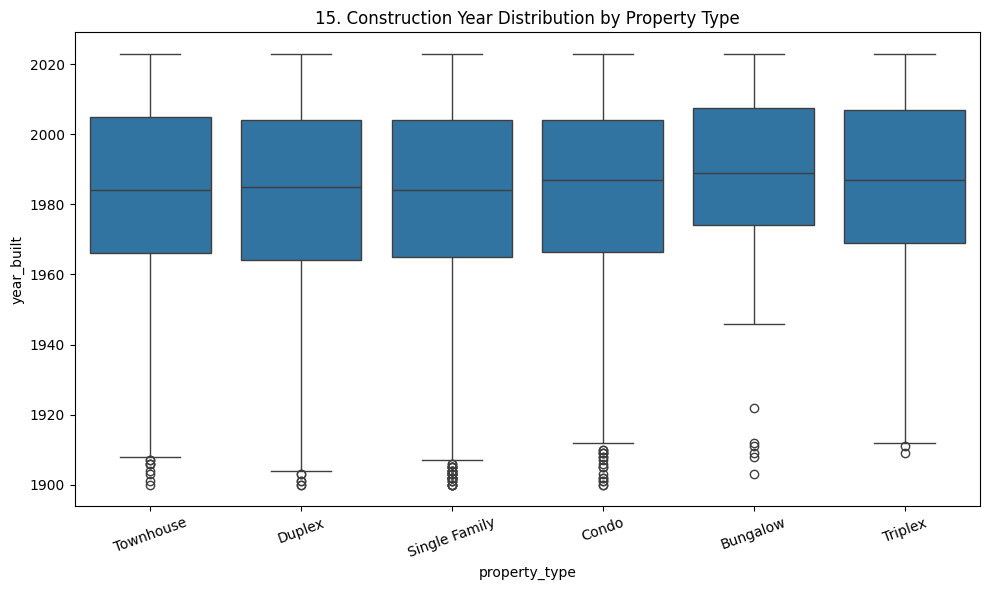

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='property_type', y='year_built', data=df)
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Construction Year Distribution by Property Type')
show_fig()
plot_no += 1

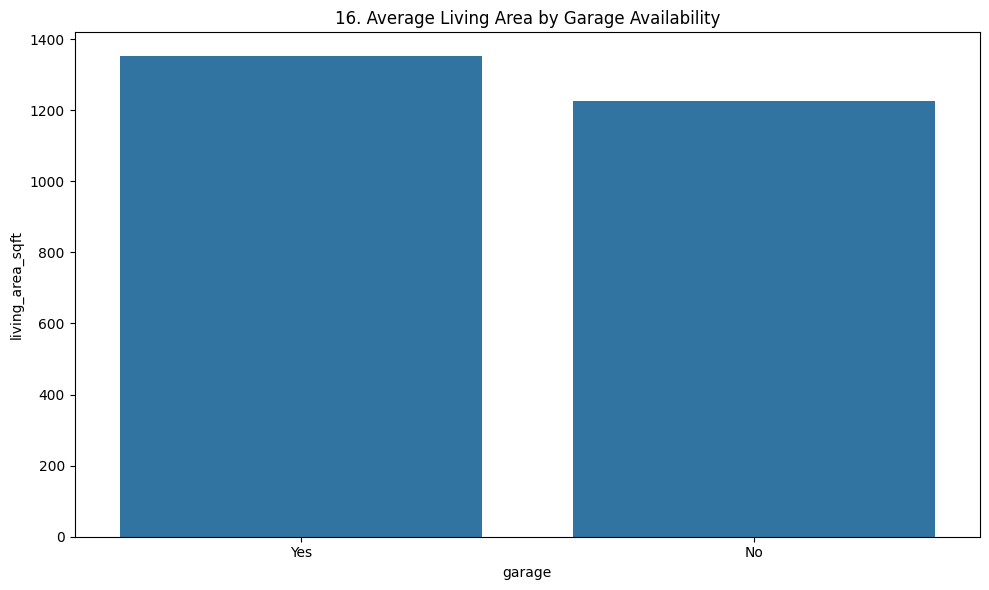

In [29]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='garage', y='living_area_sqft', data=df, estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Living Area by Garage Availability')
show_fig()
plot_no += 1

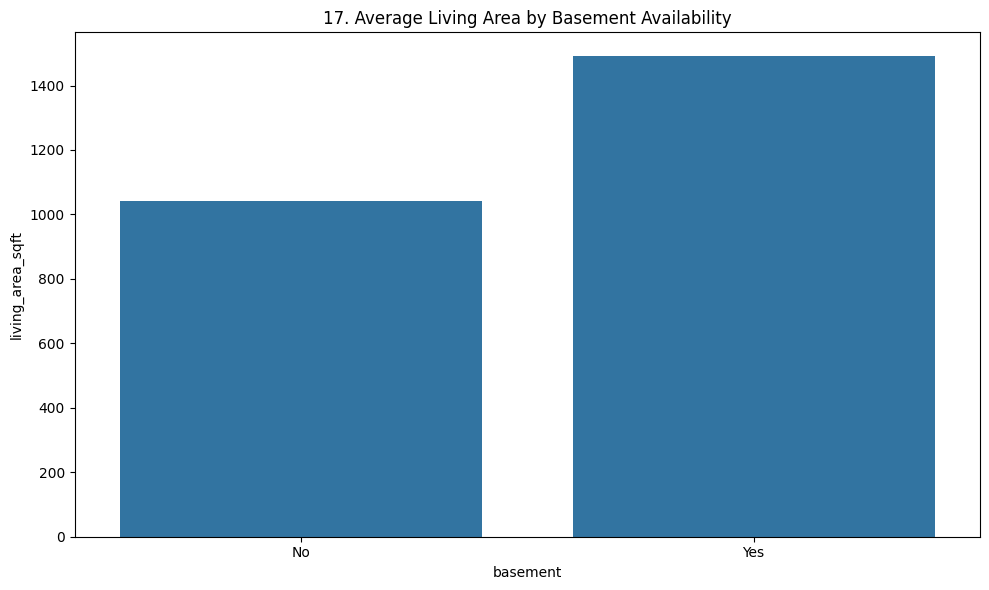

In [30]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='basement', y='living_area_sqft', data=df, estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Living Area by Basement Availability')
show_fig()
plot_no += 1

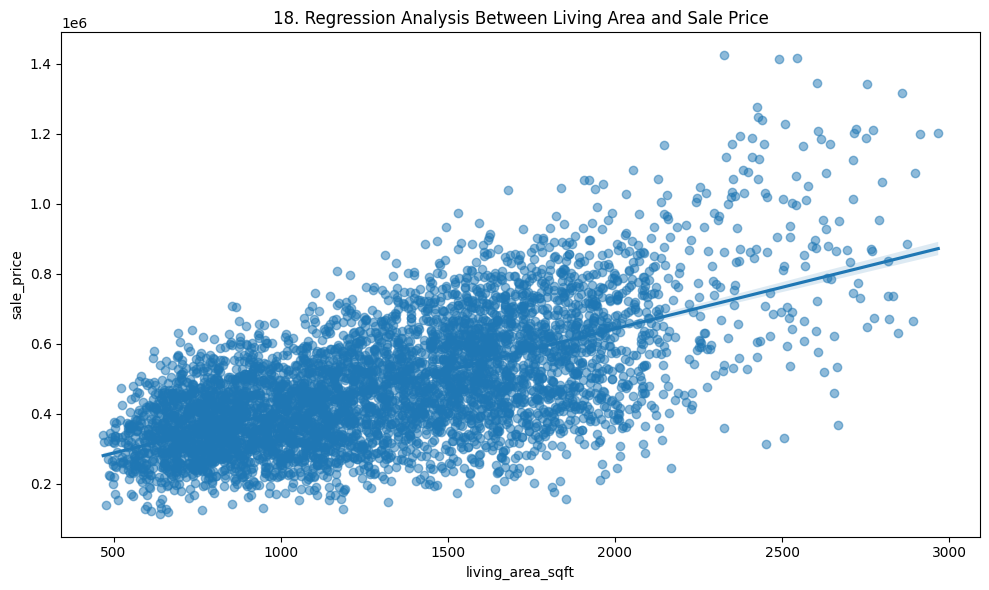

In [31]:
fig = plt.figure(figsize=(10,6))
sns.regplot(x='living_area_sqft', y='sale_price', data=df, scatter_kws={'alpha':0.5})
plt.title(f'{plot_no}. Regression Analysis Between Living Area and Sale Price')
show_fig()
plot_no += 1

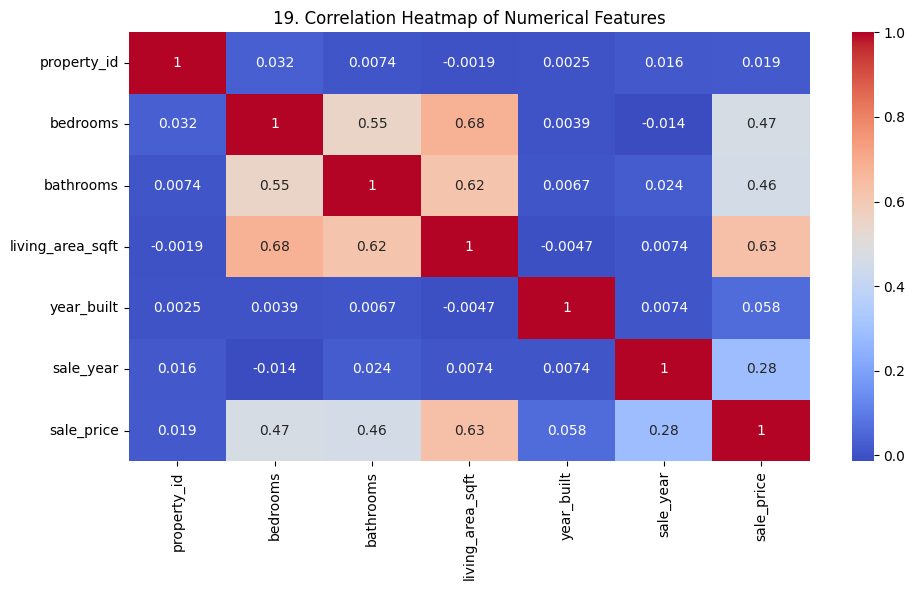

In [32]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

R² Score : 0.8933
MAE      : 43332.77
RMSE     : 56801.65


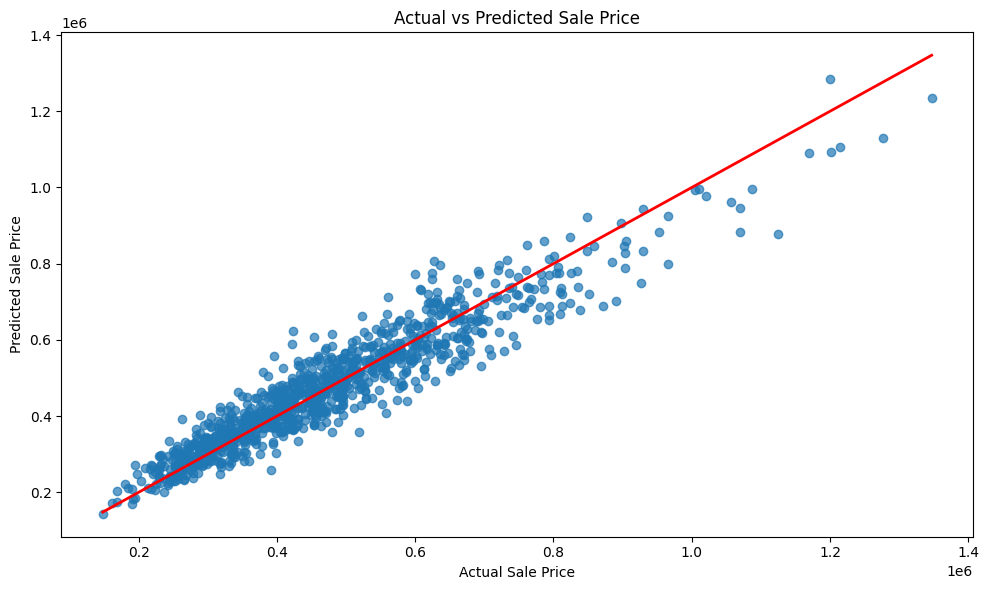

In [33]:
## Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

## Separate features and target
X = df.drop(columns=['sale_price'])
y = df['sale_price']

## Select numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

## Create numerical preprocessing pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## Create categorical preprocessing pipeline
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

## Combine preprocessing steps
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

## Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Preprocess training and testing data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## Train Gradient Boosting Regressor
model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.9,
    random_state=42
)

model.fit(X_train, y_train)

## Predict on test data
y_pred = model.predict(X_test)

## Print evaluation metrics
print("R² Score :", round(r2_score(y_test, y_pred),4))
print("MAE      :", round(mean_absolute_error(y_test, y_pred),2))
print("RMSE     :", round(np.sqrt(mean_squared_error(y_test, y_pred)),2))

## Plot Actual vs Predicted values
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Price")
plt.tight_layout()
plt.show()